In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

csv_path = "peugeot_307.csv"

listings = pd.read_csv(csv_path)

listings.head()

,title,price,negotiable,location,year,age,mileage,promoted,url
0,Peugeot 307,3100,False,A Dos Cunhados E Maceira,2003.0,23.0,103000.0,False,https://www.standvirtual.com/carros/anuncio/pe...
1,Peugeot 307 1.4 - 123000 Km,2950,False,Loures,2003.0,23.0,123000.0,False,https://www.olx.pt/d/anuncio/peugeot-307-1-4-1...
2,Vendo Peugeot 307 usado,2500,False,São João Das Lampas E Terrugem,2005.0,21.0,277578.0,False,https://www.olx.pt/d/anuncio/vendo-peugeot-307...
3,"Peugeot 307, 2004 em ótimo estado",1450,True,"Tamengos, Aguim E Óis Do Bairro",2004.0,22.0,400000.0,False,https://www.olx.pt/d/anuncio/peugeot-307-2004-...
4,Peugeot 307 1.4 XR,1800,False,Baltar,2002.0,24.0,187903.0,False,https://www.standvirtual.com/carros/anuncio/pe...


In [2]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       35 non-null     str    
 1   price       35 non-null     int64  
 2   negotiable  35 non-null     bool   
 3   location    35 non-null     str    
 4   year        28 non-null     float64
 5   age         28 non-null     float64
 6   mileage     28 non-null     float64
 7   promoted    35 non-null     bool   
 8   url         35 non-null     str    
dtypes: bool(2), float64(3), int64(1), str(3)
memory usage: 2.1 KB


In [3]:
listings.dropna(inplace=True)
listings.info()

<class 'pandas.DataFrame'>
Index: 26 entries, 0 to 34
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       26 non-null     str    
 1   price       26 non-null     int64  
 2   negotiable  26 non-null     bool   
 3   location    26 non-null     str    
 4   year        26 non-null     float64
 5   age         26 non-null     float64
 6   mileage     26 non-null     float64
 7   promoted    26 non-null     bool   
 8   url         26 non-null     str    
dtypes: bool(2), float64(3), int64(1), str(3)
memory usage: 1.7 KB


In [4]:
listings.describe()

,price,year,age,mileage
count,26.000000,26.000000,26.000000,26.000000
mean,2847.269231,2004.846154,21.153846,192972.153846
std,1673.585458,4.469383,4.469383,95998.926782
min,700.000000,2001.000000,4.000000,3000.000000
25%,1849.750000,2002.250000,21.000000,120750.000000
50%,2450.000000,2004.000000,22.000000,179000.000000
75%,3175.000000,2005.000000,23.750000,237500.000000
max,7990.000000,2022.000000,25.000000,400000.000000


In [5]:
listings["negotiable"] = listings["negotiable"].astype(int)
listings["promoted"] = listings["promoted"].astype(int)
listings = listings[listings['mileage'] > 1000]
listings.drop(columns=["title", "location", "year", "url", "promoted", "negotiable"], inplace=True)


listings.describe()

,price,age,mileage
count,26.000000,26.000000,26.000000
mean,2847.269231,21.153846,192972.153846
std,1673.585458,4.469383,95998.926782
min,700.000000,4.000000,3000.000000
25%,1849.750000,21.000000,120750.000000
50%,2450.000000,22.000000,179000.000000
75%,3175.000000,23.750000,237500.000000
max,7990.000000,25.000000,400000.000000


In [6]:
listings["log_price"] = np.log(listings["price"] + 1)

listings.drop(columns=["price"], inplace=True)

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'mileage'}>],
       [<Axes: title={'center': 'log_price'}>, <Axes: >]], dtype=object)

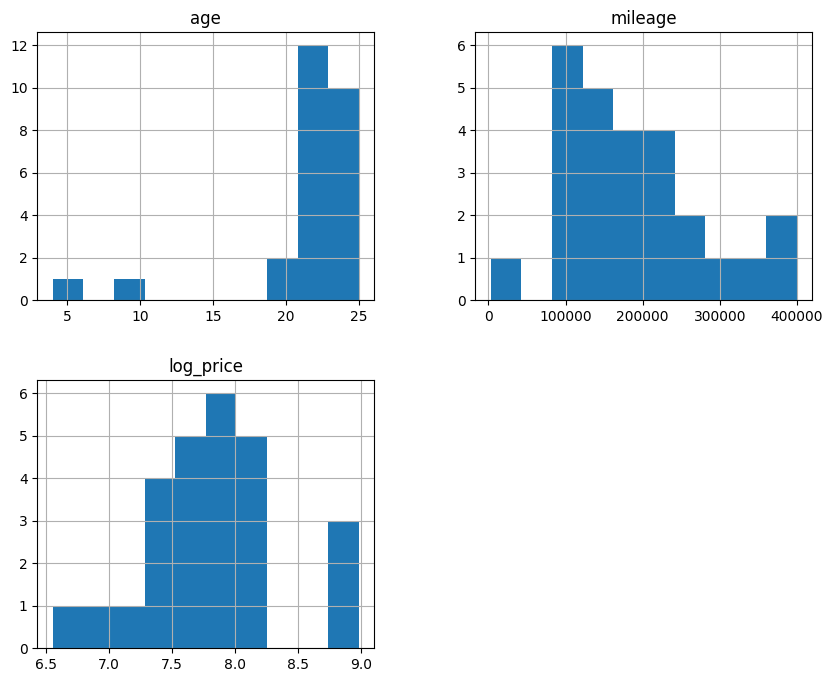

In [7]:
listings.hist(figsize=(10, 8))

<Axes: >

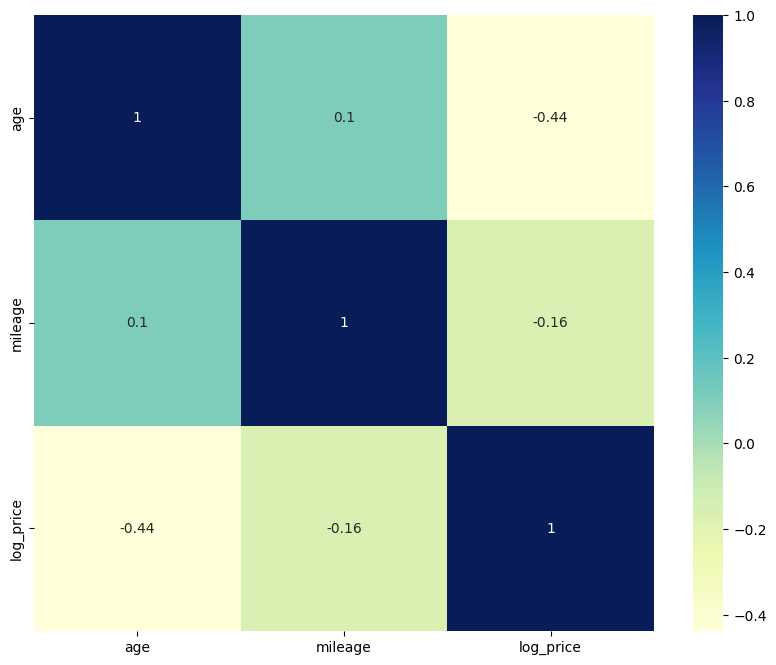

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(listings.corr(), annot=True, cmap="YlGnBu")

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = listings.drop(columns=["log_price"])
y = listings["log_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

reg.score(X_test_scaled, y_test)

-0.009954182237178255

In [11]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()
forest.fit(X_train_scaled, y_train)

forest.score(X_test_scaled, y_test)

-0.1728625925424241

In [12]:
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor()

param_grid = {
    "n_estimators": [10, 25, 50],
    "max_features": [3, 4, 5],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(forest, param_grid, cv=5, scoring="neg_mean_squared_error", return_train_score=True)

grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': [3, 4, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [10, 25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [13]:
best_forest = grid_search.best_estimator_
best_forest

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",25
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [14]:
best_forest.score(X_test_scaled, y_test)

-0.11191081913000045

In [15]:
import pandas as pd
import numpy as np


def assess_listing():
    values = {}
    print("Enter the feature values used by the linear model:")

    for column in X.columns:
        values[column] = float(input(f"{column}: "))

    print(values)
    
    listed_price = float(input("Listed price: "))

    sample = pd.DataFrame([values], columns=X.columns)
    sample_scaled = scaler.transform(sample)
    predicted_log_price = reg.predict(sample_scaled)[0]
    fair_value = np.expm1(predicted_log_price)

    difference = listed_price - fair_value
    percent_diff = (difference / fair_value) * 100 if fair_value != 0 else 0

    if abs(difference) < 1e-6:
        status = "fairly priced"
    elif difference > 0:
        status = "overpriced"
    else:
        status = "underpriced"

    print(f"\nEstimated fair value: €{fair_value:,.2f}")
    print(f"Listed price: €{listed_price:,.2f}")
    print(f"Difference: €{difference:,.2f} ({percent_diff:+.2f}%)")
    print(f"Result: The listing looks {status}.")

    return fair_value, listed_price, status


assess_listing()

Enter the feature values used by the linear model:
{'age': 18.0, 'mileage': 234000.0}

Estimated fair value: €2,913.83
Listed price: €4,500.00
Difference: €1,586.17 (+54.44%)
Result: The listing looks overpriced.


(np.float64(2913.8250711255378), 4500.0, 'overpriced')